In [3]:
!pip install xgboost shap openpyxl optuna -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 12.5 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

import matplotlib.pyplot as plt
import joblib

RANDOM_STATE = 42

In [5]:
df = pd.read_excel('BWP300DATA.xlsx')
print(f'Shape: {df.shape}')
df.head()


Shape: (300, 19)


,Usia,JK,Pendidikan,Riwayat_Keluarga,Persentase nilai identifikasi warna,Tingkat Keparahan,Kemampuan identifikasi Warna,R,I,A,S,E,C,Alat_Bantu_Penglihatan,Penyakit_Mata_Lain,Karier,JobZone,ColorReq,Label
0,17,P,SMA,Tidak,92.86,Normal,33,9,22,8,11,14,12,1,1,Data Analyst,4,Rendah,Direkomendasikan
1,34,L,S1,Ya,78.57,Ringan,27,8,11,9,22,11,8,0,1,Dokter,5,Tinggi,Direkomendasikan
2,24,L,SMA,Tidak,7.14,Berat,14,24,11,8,11,9,13,0,0,Polisi,3,Sedang,Kurang Direkomendasikan
3,26,L,D3,Tidak,92.86,Normal,31,12,10,8,12,12,23,1,0,Akuntan,4,Rendah,Direkomendasikan
4,23,L,S1,Ya,100.00,Normal,33,12,10,8,24,13,10,0,1,Guru,4,Rendah,Direkomendasikan


In [6]:
print(df.shape)

df.info()

display(df.head())

df.isnull().sum()


(300, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Usia                                 300 non-null    int64  
 1   JK                                   300 non-null    object 
 2   Pendidikan                           300 non-null    object 
 3   Riwayat_Keluarga                     300 non-null    object 
 4   Persentase nilai identifikasi warna  300 non-null    float64
 5   Tingkat Keparahan                    300 non-null    object 
 6   Kemampuan identifikasi Warna         300 non-null    int64  
 7   R                                    300 non-null    int64  
 8   I                                    300 non-null    int64  
 9   A                                    300 non-null    int64  
 10  S                                    300 non-null    int64  
 11  E                     

,Usia,JK,Pendidikan,Riwayat_Keluarga,Persentase nilai identifikasi warna,Tingkat Keparahan,Kemampuan identifikasi Warna,R,I,A,S,E,C,Alat_Bantu_Penglihatan,Penyakit_Mata_Lain,Karier,JobZone,ColorReq,Label
0,17,P,SMA,Tidak,92.86,Normal,33,9,22,8,11,14,12,1,1,Data Analyst,4,Rendah,Direkomendasikan
1,34,L,S1,Ya,78.57,Ringan,27,8,11,9,22,11,8,0,1,Dokter,5,Tinggi,Direkomendasikan
2,24,L,SMA,Tidak,7.14,Berat,14,24,11,8,11,9,13,0,0,Polisi,3,Sedang,Kurang Direkomendasikan
3,26,L,D3,Tidak,92.86,Normal,31,12,10,8,12,12,23,1,0,Akuntan,4,Rendah,Direkomendasikan
4,23,L,S1,Ya,100.00,Normal,33,12,10,8,24,13,10,0,1,Guru,4,Rendah,Direkomendasikan


,0
Usia,0
JK,0
Pendidikan,0
Riwayat_Keluarga,0
Persentase nilai identifikasi warna,0
Tingkat Keparahan,0
Kemampuan identifikasi Warna,0
R,0
I,0
A,0


In [7]:
df['Label'].value_counts()


,count
Label,
Direkomendasikan,254
Kurang Direkomendasikan,39
Tidak Direkomendasikan,7


In [8]:
data = df.copy()

X = data.drop(columns=['Label'])
y = data['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')
print(f'\nDistribusi train: {dict(pd.Series(y_train).value_counts().sort_index())}')
print(f'Distribusi test: {dict(pd.Series(y_test).value_counts().sort_index())}')

Train: 240 samples
Test:  60 samples

Distribusi train: {'Direkomendasikan': np.int64(203), 'Kurang Direkomendasikan': np.int64(31), 'Tidak Direkomendasikan': np.int64(6)}
Distribusi test: {'Direkomendasikan': np.int64(51), 'Kurang Direkomendasikan': np.int64(8), 'Tidak Direkomendasikan': np.int64(1)}


In [9]:
label_encoders = {}
categorical_features = ['JK', 'Pendidikan', 'Riwayat_Keluarga', 'Tingkat Keparahan', 'ColorReq', 'Karier']

# Fit encoder ONLY on train
for col in categorical_features:
    le = LabelEncoder()
    le.fit(X_train[col])
    X_train[col] = le.transform(X_train[col])

    # Handle unseen categories in test set
    X_test[col] = X_test[col].apply(
        lambda v: v if v in le.classes_ else le.classes_[0]
    )
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

print(f'Features: {X_train.columns.tolist()}')
print(f'Target classes: {target_encoder.classes_}')

Features: ['Usia', 'JK', 'Pendidikan', 'Riwayat_Keluarga', 'Persentase nilai identifikasi warna', 'Tingkat Keparahan', 'Kemampuan identifikasi Warna', 'R', 'I', 'A', 'S', 'E', 'C', 'Alat_Bantu_Penglihatan', 'Penyakit_Mata_Lain', 'Karier', 'JobZone', 'ColorReq']
Target classes: ['Direkomendasikan' 'Kurang Direkomendasikan' 'Tidak Direkomendasikan']


In [10]:
# SMOTE hanya di TRAIN set
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=1)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'Setelah SMOTE:')
print(f'  Train: {X_train_res.shape[0]} samples')
print(f'  Distribusi: {dict(pd.Series(y_train_res).value_counts().sort_index())}')

Setelah SMOTE:
  Train: 609 samples
  Distribusi: {0: np.int64(203), 1: np.int64(203), 2: np.int64(203)}


In [11]:
def objective(trial):
    params = {
        'objective': 'multi:softprob',
        'eval_metric': 'mlogloss',
        'random_state': RANDOM_STATE,
        'early_stopping_rounds': 50,
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for train_idx, val_idx in cv.split(X_train_res, y_train_res):
        X_tr, X_val = X_train_res.iloc[train_idx], X_train_res.iloc[val_idx]
        y_tr, y_val = y_train_res[train_idx], y_train_res[val_idx]

        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        y_pred = model.predict(X_val)
        scores.append(f1_score(y_val, y_pred, average='macro'))

    return np.mean(scores)

print('Optuna tuning... (40 trials, 3-fold CV)')
study = optuna.create_study(direction='maximize', study_name='xgb_tuning')
study.optimize(objective, n_trials=40, show_progress_bar=True)

best_params = study.best_trial.params
best_params.update({
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'random_state': RANDOM_STATE,
})

print(f'\nBest F1 Macro (CV mean): {study.best_trial.value:.4f}')
print('Best Params:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

Optuna tuning... (40 trials)


  0%|          | 0/40 [00:00<?, ?it/s]


Best F1 Macro: 1.0000
Best Params:
  n_estimators: 211
  learning_rate: 0.021656594185478925
  max_depth: 7
  min_child_weight: 4
  gamma: 0.33309589657103067
  subsample: 0.5155108672026121
  colsample_bytree: 0.8610891167881771
  reg_alpha: 2.18176215058262e-06
  reg_lambda: 0.1332437238467539
  objective: multi:softprob
  eval_metric: mlogloss
  random_state: 123


In [12]:
# Final model dengan best params + early stopping
X_fm_tr, X_fm_val, y_fm_tr, y_fm_val = train_test_split(
    X_train_res, y_train_res,
    test_size=0.15, random_state=RANDOM_STATE, stratify=y_train_res
)

final_model = XGBClassifier(**best_params, early_stopping_rounds=50)
final_model.fit(
    X_fm_tr, y_fm_tr,
    eval_set=[(X_fm_val, y_fm_val)],
    verbose=False
)

print(f'Best iteration: {final_model.best_iteration}')
print(f'Best score (mlogloss): {final_model.best_score:.4f}')

Best iteration: 210
Best score (mlogloss): 0.0797


=== TEST SET EVALUATION ===
Accuracy:  100.00%
F1 Macro:  1.0000
F1 Weighted: 1.0000

Classification Report:
                         precision    recall  f1-score   support

       Direkomendasikan       1.00      1.00      1.00        51
Kurang Direkomendasikan       1.00      1.00      1.00         8
 Tidak Direkomendasikan       1.00      1.00      1.00         1

               accuracy                           1.00        60
              macro avg       1.00      1.00      1.00        60
           weighted avg       1.00      1.00      1.00        60



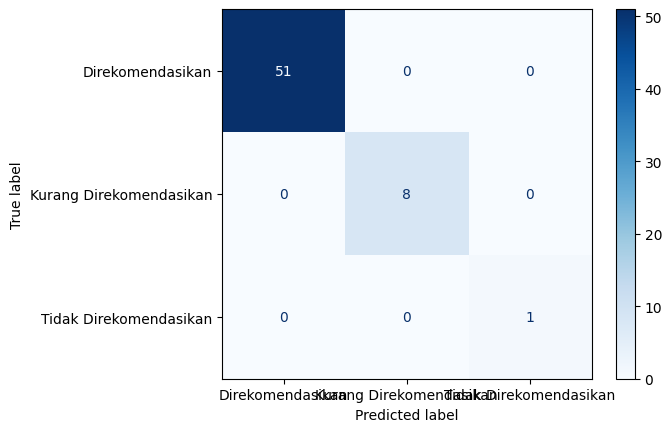

In [13]:
y_pred = final_model.predict(X_test)

print('=== TEST SET EVALUATION ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'F1 Macro:  {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'F1 Weighted: {f1_score(y_test, y_pred, average="weighted"):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred,
                            target_names=target_encoder.classes_, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)
disp.plot(cmap='Blues')
plt.show()


In [ ]:
# SHAP Analysis
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot (bar)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Bar)')
plt.tight_layout()
plt.show()

# SHAP Summary Plot (beeswarm)
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Feature Importance (Beeswarm)')
plt.tight_layout()
plt.show()

# Feature Importance dari model
importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('\nTop 10 Feature Importance:')
display(importance.head(10))

importance.head(10).plot(kind='bar', x='Feature', y='Importance', figsize=(10, 5))
plt.title('XGBoost Feature Importance (Top 10)')
plt.ylabel('Importance')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
import os
ARTIFACT_DIR = 'pipeline_artifacts/'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

joblib.dump(final_model, f'{ARTIFACT_DIR}model_production.pkl')

encoder_pack = {
    'label_encoders': label_encoders,
    'target_encoder': target_encoder,
}
joblib.dump(encoder_pack, f'{ARTIFACT_DIR}encoders.pkl')

with open(f'{ARTIFACT_DIR}best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

feature_list = X_train.columns.tolist()
with open(f'{ARTIFACT_DIR}feature_list.json', 'w') as f:
    json.dump(feature_list, f, indent=2)

print(f'✓ Artifacts saved to {ARTIFACT_DIR}/')
print('  - model_production.pkl')
print('  - encoders.pkl')
print('  - best_params.json')
print('  - feature_list.json')

✓ Artifacts saved to pipeline_artifacts//
  - model_production.pkl
  - encoders.pkl
  - best_params.json
  - feature_list.json


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Test Prediksi dari Raw Data (end-to-end test)
# ═══════════════════════════════════════════════════════════════════

# 1. Load raw data
df_raw = pd.read_excel('BWP300DATA.xlsx')
print(f'Raw data shape: {df_raw.shape}')

# 2. Separate features and true labels
X_raw = df_raw.drop(columns=['Label'])
y_raw_true = df_raw['Label']

# 3. Encode categorical features using the SAME encoders from training
X_raw_encoded = X_raw.copy()
for col in categorical_features:
    le = label_encoders[col]
    # Handle unseen categories (fallback to first known class)
    X_raw_encoded[col] = X_raw_encoded[col].apply(
        lambda v: v if v in le.classes_ else le.classes_[0]
    )
    X_raw_encoded[col] = le.transform(X_raw_encoded[col])

# 4. Predict using the trained model
y_raw_pred_encoded = final_model.predict(X_raw_encoded)
y_raw_pred = target_encoder.inverse_transform(y_raw_pred_encoded)

# 5. Build results DataFrame
results = df_raw[['Usia', 'JK', 'Karier', 'Label']].copy()
results['Predicted'] = y_raw_pred
results['Correct'] = results['Label'] == results['Predicted']

# 6. Evaluate
accuracy = accuracy_score(y_raw_true, y_raw_pred) * 100
n_correct = results['Correct'].sum()
n_total = len(results)

print(f'\n=== FULL DATA PREDICTION RESULTS ===')
print(f'Accuracy: {accuracy:.2f}% ({n_correct}/{n_total} correct)')

# 7. Show misclassifications (if any)
misclassified = results[~results['Correct']]
if len(misclassified) > 0:
    print(f'\nMisclassified ({len(misclassified)} rows):')
    print(misclassified.to_string(index=False))
else:
    print('\nAll predictions are correct!')

# 8. Classification report on full data
print(f'\n=== Classification Report (Full Data) ===')
print(classification_report(y_raw_true, y_raw_pred, zero_division=0))

# 9. Show sample predictions per class
print('=== Sample Predictions ===')
for label in sorted(y_raw_true.unique()):
    mask = y_raw_true == label
    sample = results[mask].head(3)
    print(f'\nLabel: {label}')
    for _, row in sample.iterrows():
        status = 'OK' if row['Correct'] else 'MISS'
        print(f'  [{status}] Usia={row["Usia"]}, JK={row["JK"]}, '
              f'Karier={row["Karier"]} -> Predicted: {row["Predicted"]}')